# v10b — марш на CV-невязках с затравкой (шаг В): тест vs контроль

**Что показал v10 (шаг Б, 51+ сегментов):** сеть держит невязки на уровне 3–7·10⁻⁴ (ниже допустимости FV-истины 5–8·10⁻⁴), шов 10⁻⁹, keepers 10⁻⁶ — и идёт по **гладкой ветви** через onset (размах 10⁻⁴ при 0.10 у FV). Вывод: гладкий минимум существует и на уровне допустимости; лосс + марш + RFF-сеть — три ингредиента FV — без четвёртого (возмущения) ветвь не переключают.

**Шаг В — затравка.** В шов ПЕРВОГО сегмента марша добавляется малое возмущение расхода: δG(z) = ε·G(z)·sin(πz), ε = 10⁻³ (ниже точности замыканий/эталона). Данных нет, форма по времени и момент onset не задаются: дальше система решает сама — растёт возмущение по физике или гаснет. Это стандарт линейного анализа устойчивости и то, что в FV делает округление.

**Обязательный контроль честности:** та же затравка на **устойчивом** участке (`SEED_MODE=control`, старт t*=470 ≈ 1000 s, 25 сегментов) должна **затухнуть**. Если растёт и там — мы видим не неустойчивость, а вынужденный отклик/артефакт, и результат теста не засчитывается.

**Тест:** `SEED_MODE=test`, старт t*=716 (1521 s, за ~30 сегментов до onset), 60 сегментов через onset до ~1740 s. Ворота: onset (10× рост размаха vs фон до 1600 s) 1626 s ± 15%; период 5.93 s ± 15%; сегментные как в v10. Чекпоинты `v10b_<mode>_ckpt.pt`; файлы v10 не трогаются.


In [1]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [2]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [3]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [4]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [5]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [6]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [7]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [8]:
class SmoothPINN(nn.Module):
    def __init__(self, t_end_star, width=128, depth=6, activation="tanh"):
        super().__init__()

        self.t_end_star = float(t_end_star)

        if activation == "tanh":
            act = nn.Tanh
        elif activation == "silu":
            act = nn.SiLU
        else:
            raise ValueError("activation must be 'tanh' or 'silu'")

        layers = []
        in_dim = 2

        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else width, width))
            layers.append(act())

        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0

        x = torch.cat([z_scaled, t_scaled], dim=1)
        y = self.head(self.net(x))

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [9]:
class SineLayer(nn.Module):
    def __init__(self, in_dim, out_dim, omega0=1.0, first=False):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)
        self.omega0 = omega0
        self.first = first
        self.reset_parameters()

    def reset_parameters(self):
        in_dim = self.linear.in_features
        with torch.no_grad():
            if self.first:
                bound = 1.0 / in_dim
            else:
                bound = math.sqrt(6.0 / in_dim) / self.omega0
            self.linear.weight.uniform_(-bound, bound)
            self.linear.bias.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega0 * self.linear(x))


class SirenPINN(nn.Module):
    def __init__(self, width=64, depth=4, omega0_first=30.0, omega0_hidden=1.0):
        super().__init__()
        layers = [SineLayer(2, width, omega0=omega0_first, first=True)]
        for _ in range(depth - 1):
            layers.append(SineLayer(width, width, omega0=omega0_hidden))
        self.net = nn.Sequential(*layers)
        self.head = nn.Linear(width, 4)

    def forward(self, z_star, t_star):
        x = torch.cat([z_star, t_star], dim=1)
        y = self.head(self.net(x))

        rho = F.softplus(y[:, 0:1]) + 1e-8
        G = y[:, 1:2]
        h = y[:, 2:3]
        pi = y[:, 3:4]

        return rho, G, h, pi

In [10]:
class FourierFeatures(nn.Module):
    def __init__(self, freqs=(1.0, 2.0, 4.0, 8.0)):
        super().__init__()
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, 1, -1),
        )

    def forward(self, x):
        # x: [N, 2], already scaled to [-1, 1]
        xb = x.unsqueeze(-1)                         # [N, 2, 1]
        arg = math.pi * xb * self.freqs              # [N, 2, F]

        sin = torch.sin(arg).flatten(start_dim=1)
        cos = torch.cos(arg).flatten(start_dim=1)

        return torch.cat([x, sin, cos], dim=1)


class HybridPINN(nn.Module):
    def __init__(
        self,
        t_end_star,
        width_smooth=128,
        width_fourier=64,
        depth_smooth=6,
        depth_fourier=3,
        freqs=(1.0, 2.0, 4.0, 8.0),
    ):
        super().__init__()

        self.t_end_star = float(t_end_star)
        self.fourier = FourierFeatures(freqs=freqs)

        smooth_layers = []
        in_dim = 2

        for i in range(depth_smooth):
            smooth_layers.append(nn.Linear(in_dim if i == 0 else width_smooth, width_smooth))
            smooth_layers.append(nn.Tanh())

        self.smooth_net = nn.Sequential(*smooth_layers)
        self.smooth_head = nn.Linear(width_smooth, 3)

        fourier_dim = 2 + 2 * 2 * len(freqs)

        fourier_layers = []
        for i in range(depth_fourier):
            fourier_layers.append(nn.Linear(fourier_dim if i == 0 else width_fourier, width_fourier))
            fourier_layers.append(nn.Tanh())

        self.fourier_net = nn.Sequential(*fourier_layers)
        self.fourier_head = nn.Linear(width_fourier, 3)

        self.gate_logit = nn.Parameter(torch.full((1, 3), -2.0))

        self.reset_parameters()

    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def scale_inputs(self, z, t):
        z_scaled = 2.0 * z - 1.0
        t_scaled = 2.0 * t / self.t_end_star - 1.0
        return torch.cat([z_scaled, t_scaled], dim=1)

    def forward(self, z, t):
        x = self.scale_inputs(z, t)

        y_smooth = self.smooth_head(self.smooth_net(x))

        x_fourier = self.fourier(x)
        y_fourier = self.fourier_head(self.fourier_net(x_fourier))

        gate = torch.sigmoid(self.gate_logit)

        y = y_smooth + gate * y_fourier

        G_hat = y[:, 0:1]
        h_hat = y[:, 1:2]
        Pi_hat = y[:, 2:3]

        return G_hat, h_hat, Pi_hat

In [11]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [12]:
class Sampler:
    def __init__(self, case, device, dtype=torch.float32, alpha=0.02):
        self.case = case
        self.device = device
        self.dtype = dtype
        self.alpha = alpha

        self.t_bc = torch.linspace(
            0.0,
            case.t_end_star,
            4096,
            device=device,
            dtype=dtype,
        ).reshape(-1, 1)

        z_in = torch.linspace(0.0, 3.0 * alpha, 512, device=device, dtype=dtype).reshape(-1, 1)
        z_mid = torch.linspace(3.0 * alpha, 1.0 - 3.0 * alpha, 1024, device=device, dtype=dtype).reshape(-1, 1)
        z_out = torch.linspace(1.0 - 3.0 * alpha, 1.0, 512, device=device, dtype=dtype).reshape(-1, 1)

        self.z_ic = torch.cat([z_in, z_mid, z_out], dim=0)

    def uniform(self, n, a, b):
        return a + (b - a) * torch.rand(
            n,
            1,
            device=self.device,
            dtype=self.dtype,
        )

    def time(self, n):
        n0 = int(0.10 * n)
        nk = int(0.20 * n)
        nf = n - n0 - nk

        t_full = self.uniform(nf, 0.0, self.case.t_end_star)

        t_start = self.uniform(
            n0,
            0.0,
            min(0.05 * self.case.t_end_star, self.case.t_end_star),
        )

        dt = min(0.5 * self.case.w0 / self.case.L, 0.05 * self.case.t_end_star)
        a = max(0.0, self.case.t_kink_star - dt)
        b = min(self.case.t_end_star, self.case.t_kink_star + dt)

        t_kink = self.uniform(nk, a, b)

        return torch.cat([t_full, t_start, t_kink], dim=0)

    def interior(self, n_in=2048, n_mid=4096, n_out=2048):
        a = self.alpha

        z_in = self.uniform(n_in, 0.0, 3.0 * a)
        z_mid = self.uniform(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = self.uniform(n_out, 1.0 - 3.0 * a, 1.0)

        return {
            "in": (z_in.requires_grad_(True), self.time(n_in).requires_grad_(True)),
            "mid": (z_mid.requires_grad_(True), self.time(n_mid).requires_grad_(True)),
            "out": (z_out.requires_grad_(True), self.time(n_out).requires_grad_(True)),
        }

    def bc(self):
        t = self.t_bc

        return {
            "in": (torch.zeros_like(t), t),
            "out": (torch.ones_like(t), t),
        }

    def ic(self):
        z = self.z_ic
        t = torch.zeros_like(z)

        return z, t


    # ---- causal training grid (Wang, Sankaran, Perdikaris 2024) ----------
    def causal_time_grid(self, n_t, t_lo=0.0, t_hi=None, jitter=True):
        # Sorted time grid t_1 < ... < t_Nt over (t_lo, t_hi]. linspace cells with
        # intra-cell jitter keep strict ordering (needed for the causal cumulative
        # sum). The left edge t_lo is the IC anchor (handled in causal_pde_loss).
        te = self.case.t_end_star if t_hi is None else t_hi
        edges = torch.linspace(t_lo, te, n_t + 1, device=self.device, dtype=self.dtype)
        left = edges[:-1]
        width = float(edges[1] - edges[0])
        if jitter:
            u = torch.rand(n_t, device=self.device, dtype=self.dtype)
        else:
            u = torch.full((n_t,), 0.5, device=self.device, dtype=self.dtype)
        t = left + u * width
        return t.reshape(-1, 1)

    def causal_space(self, n_t, n_z):
        # For each of n_t times, n_z spatial points spanning [0,1] with the
        # in/mid/out zone density of interior(). Returns (n_t, n_z): row i holds
        # the z's for time i, so a row-major flatten groups points by time.
        a = self.alpha
        n_in = max(1, round(0.25 * n_z))
        n_out = max(1, round(0.25 * n_z))
        n_mid = n_z - n_in - n_out

        def block(n, lo, hi):
            return lo + (hi - lo) * torch.rand(
                n_t, n, device=self.device, dtype=self.dtype,
            )

        z_in = block(n_in, 0.0, 3.0 * a)
        z_mid = block(n_mid, 3.0 * a, 1.0 - 3.0 * a)
        z_out = block(n_out, 1.0 - 3.0 * a, 1.0)
        return torch.cat([z_in, z_mid, z_out], dim=1)


In [13]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


In [14]:
class Trainer:
    def __init__(self, model, physics, sampler, weights, lr=1e-4):
        self.model = model
        self.physics = physics
        self.sampler = sampler
        self.weights = weights
        self.optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    def step(self, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        self.optimizer.zero_grad(set_to_none=True)

        loss, logs = self.physics.causal_pde_loss(
            self.sampler, self.weights, eps, t_lo, t_hi, ic_spec,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=1.0)

        self.optimizer.step()

        return {
            key: (float(value.detach().cpu()) if torch.is_tensor(value) else float(value))
            for key, value in logs.items()
        }


class StitchedModel(nn.Module):
    # Routes (z, t) to the window model that owns t, so the marched solution acts
    # as one model over [0, t_end] for all the diagnostic cells. Each submodel is
    # evaluated on all points and masked (differentiable; cheap at diagnostic
    # sizes). Windows partition time as [lo, hi) except the last, which is [lo, hi].
    def __init__(self, windows, t_end_star):
        super().__init__()
        self.submodels = nn.ModuleList([m for (_, _, m) in windows])
        self.bounds = [(float(lo), float(hi)) for (lo, hi, _) in windows]
        self.t_end_star = float(t_end_star)

    def forward(self, z, t):
        G = torch.zeros_like(z)
        H = torch.zeros_like(z)
        P = torch.zeros_like(z)
        n = len(self.bounds)
        for j, ((lo, hi), m) in enumerate(zip(self.bounds, self.submodels)):
            mask = (t >= lo) & (t < hi) if j < n - 1 else (t >= lo) & (t <= hi)
            sel = mask.to(z.dtype)
            g, h, pp = m(z, t)
            G = G + sel * g
            H = H + sel * h
            P = P + sel * pp
        return G, H, P



In [15]:
class FTSegNet(nn.Module):
    """Сеть FT-PINN (Chen+ 2026, Eq. 20-22 + Eq. 15) под интерфейс model(z,t)->(G_hat,h_hat,Pi_hat)."""

    def __init__(self, m=128, sigma_xi=1.0, sigma_tau=2.0, width=256, depth=2, seed=0):
        super().__init__()
        gen = torch.Generator().manual_seed(seed)
        # Alg. A1 шаг 4: k ~ N(0, sigma_xi^2), f ~ N(0, sigma_tau^2), фиксируются один раз
        self.register_buffer("k_vec", torch.randn(m, generator=gen) * sigma_xi)
        self.register_buffer("f_vec", torch.randn(m, generator=gen) * sigma_tau)
        # границы текущего сегмента (глобальное безразмерное время)
        self.register_buffer("t_lo", torch.tensor(0.0))
        self.register_buffer("t_hi", torch.tensor(1.0))

        layers = []
        in_dim = 2 * m
        for i in range(depth):
            # RFF выполняет роль первого sine-слоя, поэтому оба слоя транка — «скрытая» инициализация SIREN
            layers.append(SineLayer(in_dim if i == 0 else width, width, omega0=1.0, first=False))
        self.trunk = nn.Sequential(*layers)
        self.head = nn.Linear(width, 3)

    def set_segment(self, t_lo, t_hi):
        self.t_lo.fill_(float(t_lo))
        self.t_hi.fill_(float(t_hi))

    def _rff(self, x, vec):
        arg = 2.0 * math.pi * x * vec.reshape(1, -1)          # (N, m)
        return torch.cat([torch.cos(arg), torch.sin(arg)], dim=1)

    def forward(self, z, t):
        tau_hat = (t - self.t_lo) / (self.t_hi - self.t_lo)   # Eq. 13: время окна в [0,1]
        qz = self.head(self.trunk(self._rff(z, self.k_vec)))          # (N,3)
        qt = self.head(self.trunk(self._rff(tau_hat, self.f_vec)))    # (N,3)
        q = qz * qt                                                   # Eq. 22: separable-произведение

        G_hat = q[:, 0:1]
        h_hat = -1.0 + z * q[:, 1:2]                          # h*(0,t) = -NSPC тождественно
        Pi_hat = (1.0 - z) + z * (1.0 - z) * q[:, 2:3]        # imposed-dp и gauge тождественно
        return G_hat, h_hat, Pi_hat


In [16]:
class PhysicsCV(Physics):
    """Physics с интегральным (конечно-объёмным) движком PDE-невязок (Zhang+ 2026, 1D-адаптация).
    Заменён ТОЛЬКО _per_time_residual: causal_pde_loss/keepers/BC/IC наследуются."""

    def __init__(self, *args, n_cv=128, w_bnd=0.06, **kw):
        super().__init__(*args, **kw)
        self.n_cv = int(n_cv)
        self.w_bnd = float(w_bnd)

    def _cv_grid(self, device, dtype):
        # граничные CV [0, w_bnd] и [1-w_bnd, 1] (зона локальных потерь), внутри равномерно
        inner = torch.linspace(self.w_bnd, 1.0 - self.w_bnd, self.n_cv - 1, device=device, dtype=dtype)
        faces = torch.cat([torch.zeros(1, device=device, dtype=dtype), inner,
                           torch.ones(1, device=device, dtype=dtype)])
        mids = 0.5 * (faces[1:] + faces[:-1])
        dz = faces[1:] - faces[:-1]
        return faces, mids, dz

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        Nt = t_grid.shape[0]
        device, dtype = t_grid.device, t_grid.dtype
        faces, mids, dz = self._cv_grid(device, dtype)
        Nf, Nc = faces.numel(), mids.numel()

        # --- грани: потоки (z-производные не нужны, автоград только по t в центрах) ---
        Zf = faces.reshape(1, Nf).expand(Nt, Nf).reshape(-1, 1)
        Tf = t_grid.reshape(-1, 1).repeat_interleave(Nf, dim=0)
        G_f, h_f, pi_f, _, _, _ = self.fields(Zf, Tf)
        rho_f, _ = self.eos25(h_f)
        M_f = lambda x: x.reshape(Nt, Nf)
        flux_f = M_f(G_f ** 2 / rho_f + pi_f)
        Gh_f = M_f(G_f * h_f)
        Gm_f = M_f(G_f)

        # --- центры: объёмные члены с d/dt автоградом ---
        Zm = mids.reshape(1, Nc).expand(Nt, Nc).reshape(-1, 1)
        Tm = t_grid.reshape(-1, 1).repeat_interleave(Nc, dim=0).clone().requires_grad_(True)
        G_m, h_m, _, _, _, _ = self.fields(Zm, Tm)
        rho_m, chi_m = self.eos25(h_m)
        G_t = d(G_m, Tm)
        h_t = d(h_m, Tm)
        Lambda_dyn, slf, _, _ = self.distributed_friction(G=G_m, h=h_m, rho=rho_m)
        NQ = self.NQ_prime(Tm)
        M_c = lambda x: x.reshape(Nt, Nc)
        dzr = dz.reshape(1, Nc)

        # масса: ∫χ h_t dz + [G]
        R_mass = M_c(chi_m * h_t) * dzr + (Gm_f[:, 1:] - Gm_f[:, :-1])
        # импульс: ∫G_t dz + [G²/ρ+π] + ∫(ρ/Fr + трение) dz + скачки в граничных CV
        R_mom = (M_c(G_t) * dzr
                 + (flux_f[:, 1:] - flux_f[:, :-1])
                 + M_c(rho_m / self.case.Fr + Lambda_dyn * slf) * dzr)
        lfn_f = M_f(G_f * smooth_abs(G_f, eps=1e-6))
        rho_fm = M_f(rho_f)
        jump_in = 0.5 * self.case.kin * lfn_f[:, 0] / rho_fm[:, 0]
        jump_out = 0.5 * self.case.kout * lfn_f[:, -1] / rho_fm[:, -1]
        R_mom = R_mom.clone()
        R_mom[:, 0] = R_mom[:, 0] + jump_in
        R_mom[:, -1] = R_mom[:, -1] + jump_out
        # энергия: ∫(ρ+hχ) h_t dz + [G h] − ∫N_Q' dz
        R_energy = (M_c((rho_m + h_m * chi_m) * h_t) * dzr
                    + (Gh_f[:, 1:] - Gh_f[:, :-1])
                    - M_c(NQ) * dzr)

        # интенсивная нормировка: /Δz и штатные масштабы — пол сравним с точечным AD
        R_mass = R_mass / (dzr * self.case.mass_scale)
        R_mom = R_mom / (dzr * self.case.mom_mid_scale)
        R_energy = R_energy / (dzr * self.case.energy_scale)

        Lr_pde = (weights.mass * (R_mass ** 2).mean(dim=1)
                  + weights.mom * (R_mom ** 2).mean(dim=1)
                  + weights.energy * (R_energy ** 2).mean(dim=1))

        # --- BC per-time (штатный imposed-Δp) — дословно из Physics ---
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)

        # --- IC-якорь — дословно из Physics ---
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"])
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {"pde": Lr_pde.mean().detach(), "bc": Lr_bc.mean().detach(), "ic": L_ic.detach()}
        return Lr_pde, L0, Lr_bc, parts


In [17]:
import os
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32
torch.manual_seed(0)

sampler = Sampler(case=case, device=device, dtype=dtype, alpha=0.02)
model = FTSegNet(m=128, sigma_xi=1.0, sigma_tau=2.0, width=256, depth=2, seed=0).to(device=device, dtype=dtype)
physics = PhysicsCV(model, eos, mu_spline, case, forcing, alpha=0.02, n_cv=128, w_bnd=0.06)
weights = LossWeights(mass=2.0, mom=0.25, energy=0.5, mom_integral=20.0, energy_integral=20.0, mass_integral=20.0)
SEAM_WEIGHT = 1.0e4

# гладкое прошлое: полированный v9 (fallback — v9 full)
smooth = SmoothPINN(t_end_star=case.t_end_star, width=128, depth=6, activation="tanh").to(device=device, dtype=dtype)
SMOOTH_SRC = "v9a_polish.pt" if Path("v9a_polish.pt").exists() else "v9_lsfvp.pt"
smooth.load_state_dict(torch.load(SMOOTH_SRC, map_location=device, weights_only=False)["model"])
print("гладкое прошлое:", SMOOTH_SRC)

SEED_MODE = os.environ.get("SEED_MODE", "test")          # test | control  <-- для ручного прогона задай здесь: SEED_MODE = "control"
SEED_EPS = float(os.environ.get("SEED_EPS", "1e-3"))       # относительная амплитуда затравки
T_START = {"test": 716.0, "control": 470.0}[SEED_MODE]    # t*: 1521 s (за ~30 сегм. до onset) | 1000 s (устойчивый участок)
DGAMMA = 1.6
edges = [T_START]
while edges[-1] < case.t_end_star - 1e-9:
    edges.append(min(edges[-1] + DGAMMA, case.t_end_star))
SCHEDULE = list(zip(edges[:-1], edges[1:]))
PRESETS = {
    "selftest": dict(n_seg=2, adam=30, lbfgs_rounds=0, lbfgs_steps=0, Nt=16),
    "smoke":    dict(n_seg=3, adam=1500, lbfgs_rounds=1, lbfgs_steps=150, Nt=64),
    "full":     dict(n_seg={"test": 60, "control": 25}[SEED_MODE], adam=1500, lbfgs_rounds=4, lbfgs_steps=300, Nt=64),
}
RUN_PRESET = os.environ.get("V10_PRESET", "smoke"); P = PRESETS[RUN_PRESET]
RESUME = True; CKPT_PATH = Path(f"v10b_{SEED_MODE}_ckpt.pt")
GATE_PDE, GATE_SEAM, GATE_KEEPER = 3.0e-3, 3.0e-4, 1.0e-3
print(f"SEED_MODE={SEED_MODE} eps={SEED_EPS:g}"); print(f"preset={RUN_PRESET}: {P}; сегментов {len(SCHEDULE)} по {DGAMMA} t* от {T_START} t* ({T_START*case.L/case.w0:.0f} s); {device}")


гладкое прошлое: v9a_polish.pt
SEED_MODE=test eps=0.001
preset=smoke: {'n_seg': 3, 'adam': 1500, 'lbfgs_rounds': 1, 'lbfgs_steps': 150, 'Nt': 64}; сегментов 82 по 1.6 t* от 716.0 t* (1521 s); cuda


In [18]:
def seg_loss(t_grid, ic_spec):
    Lr_pde, _, _, parts = physics._per_time_residual(sampler, weights, t_grid)   # CV-невязки окна
    L_pde = Lr_pde.mean()
    ic = physics.ic_loss_target(ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"])
    L_ic = ic["ic_G"] + ic["ic_h"]
    mom_vec, en_vec, ma_vec = physics._keeper_vectors(t_grid, n_z=193)
    K_mom, K_en, K_ma = mse(mom_vec), mse(en_vec), mse(ma_vec)
    L_keeper = weights.mom_integral*K_mom + weights.energy_integral*K_en + weights.mass_integral*K_ma
    total = L_pde + SEAM_WEIGHT*L_ic + L_keeper
    return total, {"loss": total, "pde": L_pde, "seam": L_ic, "keeper": K_mom+K_en+K_ma}

def _f(logs): return {k: (float(v.detach().cpu()) if torch.is_tensor(v) else float(v)) for k, v in logs.items()}

def _eval(t_lo, t_hi, ic_spec):
    t_grid = sampler.causal_time_grid(P["Nt"], t_lo=t_lo, t_hi=t_hi)
    return _f(seg_loss(t_grid, ic_spec)[1])

def train_segment(i, t_lo, t_hi, ic_spec, print_every=250):
    model.set_segment(t_lo, t_hi); hist = []
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    for n in range(1, P["adam"]+1):
        t_grid = sampler.causal_time_grid(P["Nt"], t_lo=t_lo, t_hi=t_hi)
        opt.zero_grad(set_to_none=True)
        loss, logs = seg_loss(t_grid, ic_spec); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
        logs = _f(logs); hist.append(logs)
        if n % print_every == 0 or n == P["adam"]:
            print(f"  [{i:3d}] adam {n:4d}  loss={logs['loss']:.3e} pde={logs['pde']:.3e} seam={logs['seam']:.3e} keeper={logs['keeper']:.3e}")
    best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}; best = _eval(t_lo, t_hi, ic_spec)["loss"]
    for r in range(P["lbfgs_rounds"]):
        t_grid = sampler.causal_time_grid(P["Nt"], t_lo=t_lo, t_hi=t_hi)
        lb = torch.optim.LBFGS(model.parameters(), max_iter=P["lbfgs_steps"], history_size=50, line_search_fn="strong_wolfe")
        def closure():
            lb.zero_grad(set_to_none=True); loss, _ = seg_loss(t_grid, ic_spec); loss.backward(); return loss
        try: lb.step(closure)
        except Exception as e: print(f"  [{i:3d}] lbfgs {r}: {type(e).__name__} — откат")
        cur = _eval(t_lo, t_hi, ic_spec)
        if math.isfinite(cur["loss"]) and cur["loss"] < best:
            best = cur["loss"]; best_sd = {k: v.detach().clone() for k, v in model.state_dict().items()}; hist.append(cur)
            print(f"  [{i:3d}] lbfgs {r}: loss={cur['loss']:.3e}")
        else:
            model.load_state_dict(best_sd); print(f"  [{i:3d}] lbfgs {r}: {cur['loss']:.3e} не лучше — реактивация")
    model.load_state_dict(best_sd)
    fin = _eval(t_lo, t_hi, ic_spec)
    gate = {"gate_pde": fin["pde"] < GATE_PDE, "gate_seam": fin["seam"] < GATE_SEAM, "gate_keeper": fin["keeper"] < GATE_KEEPER}
    print(f"  [{i:3d}] ворота {'PASS' if all(gate.values()) else 'FAIL'}: pde={fin['pde']:.3e} seam={fin['seam']:.3e} keeper={fin['keeper']:.3e}")
    return hist, fin, gate


In [19]:
def curves(t_lo, t_hi, n=64):
    with torch.no_grad():
        tt = torch.linspace(t_lo, t_hi, n, device=device, dtype=dtype).reshape(-1,1)
        Gi, _, _, _, _, _ = physics.fields(torch.zeros_like(tt), tt); Go, _, _, _, _, _ = physics.fields(torch.ones_like(tt), tt)
    k = case.mdot0/case.G0_star
    return (tt.reshape(-1)*case.L/case.w0).cpu().numpy(), (Gi.reshape(-1)*k).cpu().numpy(), (Go.reshape(-1)*k).cpu().numpy()

state = {"done": 0, "segments": [], "hist": [], "gates": [], "t_sec": [], "Gin_kgs": [], "Gout_kgs": []}
if RESUME and CKPT_PATH.exists():
    state = torch.load(CKPT_PATH, map_location=device, weights_only=False)["state"]
    model.load_state_dict({k: v.to(device) for k, v in state["segments"][-1]["state_dict"].items()})
    print(f"resume: {state['done']} сегментов")

n_run = min(P["n_seg"], len(SCHEDULE))
for i in range(state["done"], n_run):
    t_lo, t_hi = SCHEDULE[i]
    if i == 0:
        physics.model = smooth                       # шов к полированному v9 при T_START
        G_prev, h_prev = physics.snapshot_state(sampler.z_ic, t_lo)
        physics.model = model
        # === ЗАТРАВКА (шаг В): δG = eps·G·sin(πz) в шов первого сегмента, только здесь ===
        G_prev = G_prev * (1.0 + SEED_EPS * torch.sin(math.pi * sampler.z_ic))
        print(f"затравка: eps={SEED_EPS:g}, max|δG|/G0*={float((SEED_EPS*torch.sin(math.pi*sampler.z_ic)*G_prev).abs().max()/case.G0_star):.2e}")
    else:
        G_prev, h_prev = physics.snapshot_state(sampler.z_ic, t_lo)   # модель = конец сегмента i-1
    ic_spec = {"z": sampler.z_ic, "t_at": t_lo, "G": G_prev, "h": h_prev}
    print(f"=== сегмент {i+1}/{n_run}: t* [{t_lo:.1f},{t_hi:.1f}] ({t_lo*case.L/case.w0:.1f}-{t_hi*case.L/case.w0:.1f} s) ===")
    hist, fin, gate = train_segment(i, t_lo, t_hi, ic_spec)
    ts, gi, go = curves(t_lo, t_hi)
    state["hist"].append(hist); state["gates"].append({"seg": i, "t_lo": t_lo, "t_hi": t_hi, **fin, **gate})
    state["t_sec"].append(ts); state["Gin_kgs"].append(gi); state["Gout_kgs"].append(go)
    state["segments"].append({"t_lo": t_lo, "t_hi": t_hi, "state_dict": {k: v.detach().cpu() for k, v in model.state_dict().items()}})
    state["done"] = i+1
    torch.save({"state": state}, CKPT_PATH)
n_pass = sum(1 for g_ in state["gates"] if g_["gate_pde"] and g_["gate_seam"] and g_["gate_keeper"])
print(f"\nмарш: {state['done']} сегментов, ворота PASS {n_pass}/{len(state['gates'])}")


resume: 60 сегментов

марш: 60 сегментов, ворота PASS 58/60


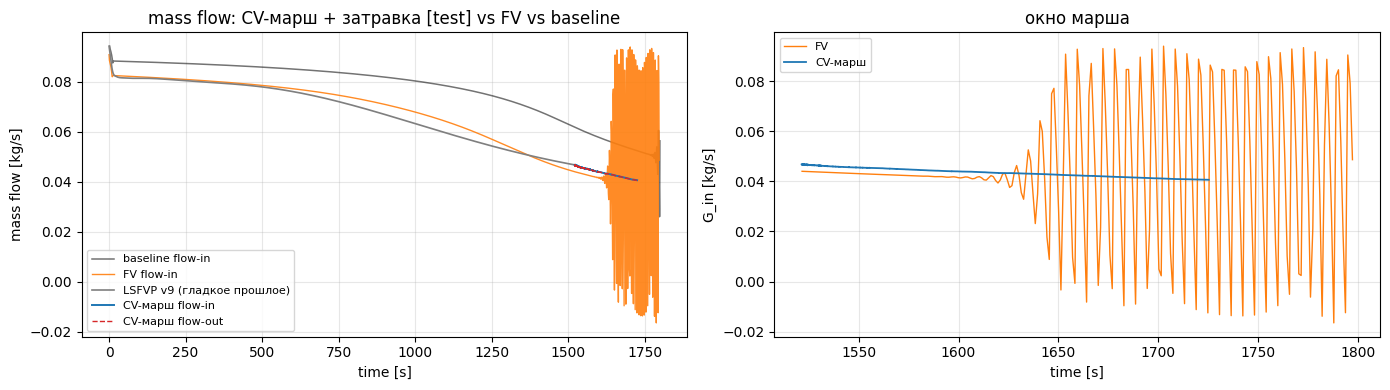

 seg  t_lo  t_hi      pde         seam       keeper  PASS
   0 716.0 717.6 0.008660 2.061959e-07 6.819016e-05 False
   1 717.6 719.2 0.004097 2.246174e-08 1.540689e-05 False
   2 719.2 720.8 0.002435 1.272256e-08 1.612074e-05  True
   3 720.8 722.4 0.001621 8.653098e-09 1.289495e-05  True
   4 722.4 724.0 0.001085 8.066593e-09 9.563345e-06  True
   5 724.0 725.6 0.001206 4.302809e-09 1.153543e-05  True
   6 725.6 727.2 0.000954 3.685407e-09 7.582480e-06  True
   7 727.2 728.8 0.000903 3.818064e-09 6.482956e-06  True
   8 728.8 730.4 0.000682 7.781661e-09 7.064272e-06  True
   9 730.4 732.0 0.000711 5.241970e-09 7.903942e-06  True
  10 732.0 733.6 0.000645 4.391836e-09 5.471062e-06  True
  11 733.6 735.2 0.000651 4.765424e-09 5.639423e-06  True
  12 735.2 736.8 0.000545 5.463181e-09 4.658180e-06  True
  13 736.8 738.4 0.000595 3.098235e-09 4.385317e-06  True
  14 738.4 740.0 0.000656 1.996058e-09 4.677991e-06  True
  15 740.0 741.6 0.000515 5.757860e-09 3.582547e-06  True
  16 741.6 743

In [20]:
t_sec = np.concatenate(state["t_sec"]); Gin = np.concatenate(state["Gin_kgs"]); Gout = np.concatenate(state["Gout_kgs"])
ref = np.load("fv_reference_curve.npz")
# гладкое прошлое (v9) до T_START для полной картины
with torch.no_grad():
    physics.model = smooth
    tt = torch.linspace(0.0, T_START, 800, device=device, dtype=dtype).reshape(-1,1)
    Gs, _, _, _, _, _ = physics.fields(torch.zeros_like(tt), tt); physics.model = model
ts_s = (tt.reshape(-1)*case.L/case.w0).cpu().numpy(); gs = (Gs.reshape(-1)*case.mdot0/case.G0_star).cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(forcing.time, forcing.flow_in, color="k", lw=1.1, alpha=0.55, label="baseline flow-in")
ax[0].plot(ref["t_sec"], ref["Gin_kgs"], color="tab:orange", lw=1.0, alpha=0.9, label="FV flow-in")
ax[0].plot(ts_s, gs, color="tab:gray", lw=1.2, label="LSFVP v9 (гладкое прошлое)")
ax[0].plot(t_sec, Gin, color="tab:blue", lw=1.4, label="CV-марш flow-in")
ax[0].plot(t_sec, Gout, "--", color="tab:red", lw=1.0, label="CV-марш flow-out")
ax[0].set_xlabel("time [s]"); ax[0].set_ylabel("mass flow [kg/s]"); ax[0].set_title(f"mass flow: CV-марш + затравка [{SEED_MODE}] vs FV vs baseline"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
m = ref["t_sec"] >= t_sec[0]
ax[1].plot(ref["t_sec"][m], ref["Gin_kgs"][m], color="tab:orange", lw=1.0, label="FV")
ax[1].plot(t_sec, Gin, color="tab:blue", lw=1.3, label="CV-марш")
ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("G_in [kg/s]"); ax[1].set_title("окно марша"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

gdf = pd.DataFrame(state["gates"]); gdf["PASS"] = gdf.gate_pde & gdf.gate_seam & gdf.gate_keeper
print(gdf[["seg","t_lo","t_hi","pde","seam","keeper","PASS"]].to_string(index=False))

# DWO-ворота (если покрыт хвост)
if SEED_MODE == "test" and t_sec[-1] > 1650.0:
    w = 20
    p2p = np.array([np.ptp(Gin[max(0,j-w):j+w]) for j in range(len(Gin))])
    base_p2p = p2p[t_sec < 1560.0].mean() if (t_sec < 1560.0).sum() > 40 else p2p[:60].mean()
    hit = np.where(p2p > 10*base_p2p)[0]
    onset = float(t_sec[hit[0]]) if len(hit) else float("nan")
    mt = t_sec > 1650.0; s = Gin[mt]-Gin[mt].mean(); dt_s = float(np.mean(np.diff(t_sec[mt])))
    fr = np.fft.rfftfreq(len(s), d=dt_s); sp = np.abs(np.fft.rfft(s)); period = 1.0/fr[int(np.argmax(sp[1:]))+1]
    print(f"DWO: onset {onset:.0f} s (1626±15%: {'PASS' if abs(onset-1626)/1626<=0.15 else 'FAIL'}), период {period:.2f} s (5.93±15%: {'PASS' if abs(period-5.93)/5.93<=0.15 else 'FAIL'}), размах хвоста {np.ptp(Gin[mt]):.4f} kg/s (FV {np.ptp(ref['Gin_kgs'][ref['t_sec']>1650]):.4f})")
elif SEED_MODE == "control":
    w = 20
    p2p = np.array([np.ptp(Gin[max(0,j-w):j+w]) for j in range(len(Gin))])
    seg_p2p = [float(np.ptp(x)) for x in state["Gin_kgs"]]
    print("контроль (устойчивый участок): посегментный размах:", " ".join(f"{v:.1e}" for v in seg_p2p))
    print(f"контроль: размах первые 5 сегм. {np.mean(seg_p2p[:5]):.2e} -> последние 5 {np.mean(seg_p2p[-5:]):.2e}  "
          f"({'ЗАТУХЛА — контроль PASS' if np.mean(seg_p2p[-5:]) < np.mean(seg_p2p[:5]) else 'НЕ ЗАТУХЛА — контроль FAIL, тест не засчитывать'})")
else:
    print("DWO-ворота: хвост не покрыт")


## Сводка шага В (из готовых чекпоинтов, без пересчёта)

Три кривые на одних окнах: FV-эталон, v10 (марш без затравки) и v10b-тест (та же машинерия + затравка δG = 10⁻³·G·sin πz в шов первого окна). Справа — контроль: та же затравка на устойчивом участке (~1000 s) обязана затухнуть, иначе тест не засчитывается. Ячейка читает `v10b_test_ckpt.pt`, `v10b_control_ckpt.pt`, `v10_cvmarch_ckpt.pt`; отсутствующие пропускает.


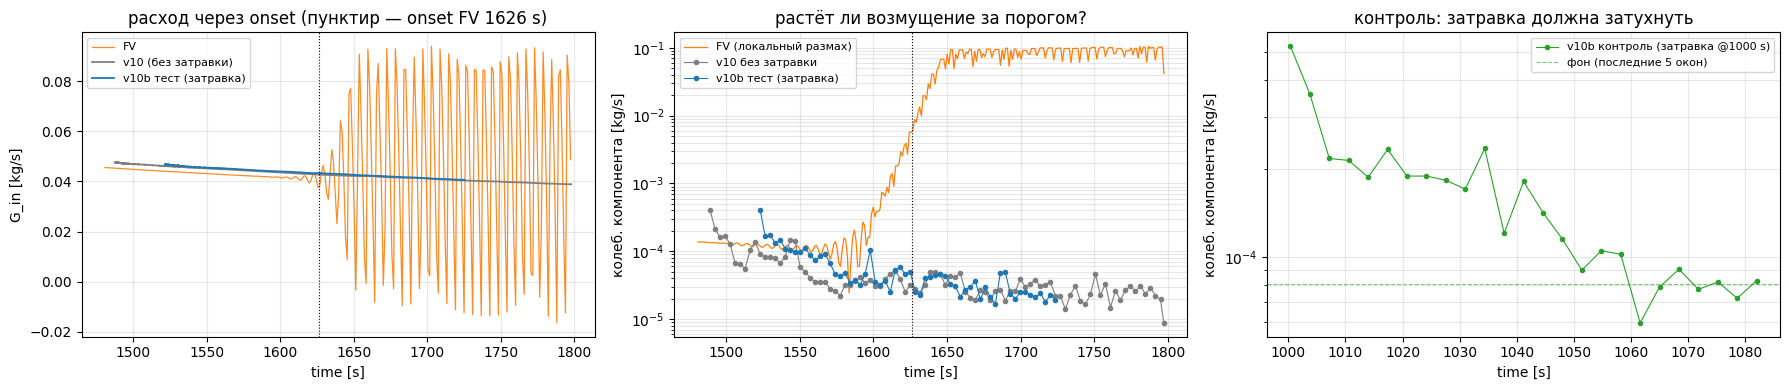

окно          v10 без затравки  тест затравка  FV размах
1520-1560s          8.38e-05       1.49e-04   1.26e-03
1560-1600s          3.29e-05       5.88e-05   1.29e-03
1600-1627s          3.69e-05       4.19e-05   5.69e-03
1627-1660s          3.96e-05       3.49e-05   9.61e-02
1660-1700s          2.49e-05       2.88e-05   1.03e-01
1700-1740s          2.83e-05       2.19e-05   1.08e-01

рост за 1596→1627 s: тест ×0.39   FV ×25
контроль: размах первые 5 окон 3.00e-04 -> последние 5 8.11e-05  (ЗАТУХЛА — PASS)


In [21]:
# === Сводка шага В: тест vs контроль vs v10 (без затравки) vs FV — из готовых чекпоинтов ===
def _load_state(p):
    return torch.load(p, map_location="cpu", weights_only=False)["state"] if Path(p).exists() else None
S_test, S_ctrl, S_v10 = _load_state("v10b_test_ckpt.pt"), _load_state("v10b_control_ckpt.pt"), _load_state("v10_cvmarch_ckpt.pt")
ref = np.load("fv_reference_curve.npz")

def _osc(st):
    """колебательная компонента по окнам: остаток от линейного тренда внутри окна (kg/s)"""
    T, A = [], []
    for ts, gi in zip(st["t_sec"], st["Gin_kgs"]):
        p = np.polyfit(ts - ts[0], gi, 1); A.append(np.ptp(gi - np.polyval(p, ts - ts[0]))); T.append(0.5*(ts[0]+ts[-1]))
    return np.array(T), np.array(A)

fig, ax = plt.subplots(1, 3, figsize=(18, 4))
# (1) расход через onset
m = ref["t_sec"] >= 1480
ax[0].plot(ref["t_sec"][m], ref["Gin_kgs"][m], color="tab:orange", lw=0.9, alpha=0.9, label="FV")
if S_v10:  ax[0].plot(np.concatenate(S_v10["t_sec"]),  np.concatenate(S_v10["Gin_kgs"]),  color="tab:gray", lw=1.3, label="v10 (без затравки)")
if S_test: ax[0].plot(np.concatenate(S_test["t_sec"]), np.concatenate(S_test["Gin_kgs"]), color="tab:blue", lw=1.3, label="v10b тест (затравка)")
ax[0].axvline(1626, ls=":", color="k", lw=0.8); ax[0].set_xlabel("time [s]"); ax[0].set_ylabel("G_in [kg/s]")
ax[0].set_title("расход через onset (пунктир — onset FV 1626 s)"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
# (2) колебательная компонента по окнам (лог) — тест vs v10 vs FV
w = 20
Tf = ref["t_sec"]; Af = np.array([np.ptp(ref["Gin_kgs"][max(0,j-2):j+2]) for j in range(len(Tf))])
ax[1].semilogy(Tf[m], np.maximum(Af[m], 1e-6), color="tab:orange", lw=0.9, label="FV (локальный размах)")
if S_v10:  T, A = _osc(S_v10);  ax[1].semilogy(T, A, "o-", ms=3, lw=0.8, color="tab:gray", label="v10 без затравки")
if S_test: T, A = _osc(S_test); ax[1].semilogy(T, A, "o-", ms=3, lw=0.8, color="tab:blue", label="v10b тест (затравка)")
ax[1].axvline(1626, ls=":", color="k", lw=0.8); ax[1].set_xlabel("time [s]"); ax[1].set_ylabel("колеб. компонента [kg/s]")
ax[1].set_title("растёт ли возмущение за порогом?"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")
# (3) контроль: затухание на устойчивом участке
if S_ctrl:
    T, A = _osc(S_ctrl); ax[2].semilogy(T, A, "o-", ms=3, lw=0.8, color="tab:green", label="v10b контроль (затравка @1000 s)")
    ax[2].axhline(np.mean(A[-5:]), ls="--", color="tab:green", lw=0.8, alpha=0.6, label="фон (последние 5 окон)")
ax[2].set_xlabel("time [s]"); ax[2].set_ylabel("колеб. компонента [kg/s]"); ax[2].set_title("контроль: затравка должна затухнуть")
ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()

# числа
def _win(st, lo, hi):
    T, A = _osc(st); mm = (T>=lo)&(T<hi); return float(A[mm].mean()) if mm.any() else float("nan")
if S_test and S_v10:
    fm = lambda lo, hi: float(np.ptp(ref["Gin_kgs"][(ref["t_sec"]>=lo)&(ref["t_sec"]<hi)]))
    print(f"{'окно':12s} {'v10 без затравки':>17s} {'тест затравка':>14s} {'FV размах':>10s}")
    for lo, hi in [(1520,1560),(1560,1600),(1600,1627),(1627,1660),(1660,1700),(1700,1740)]:
        print(f"{lo}-{hi}s {_win(S_v10,lo,hi):17.2e} {_win(S_test,lo,hi):14.2e} {fm(lo,hi):10.2e}")
    a0, a1 = _win(S_test,1596,1600), _win(S_test,1620,1630)
    print(f"\nрост за 1596→1627 s: тест ×{a1/a0:.2f}   FV ×{fm(1620,1630)/fm(1596,1600):.0f}")
if S_ctrl:
    T, A = _osc(S_ctrl)
    print(f"контроль: размах первые 5 окон {A[:5].mean():.2e} -> последние 5 {A[-5:].mean():.2e}  ({'ЗАТУХЛА — PASS' if A[-5:].mean() < A[:5].mean() else 'НЕ затухла — FAIL'})")
